In [ ]:
import importlib.util
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

import matrix_envs  # registers the env ids; also lets us read each game's true optimum

PROJECT = Path.cwd()


_spec = importlib.util.spec_from_file_location("run_sweep", PROJECT / "scripts" / "run_sweep.py")
sweep = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(sweep)

## Sweep grid — edit this cell to define a sweep

In [10]:
ALGS = {  # epymarl --config name -> display label
    "iql_ns": "IQL",
    "vdn_ns": "VDN",
    "qmix_ns": "QMIX",
    "qtran_ns": "QTRAN",
    "pac_ns": "PAC",
    "pac_dcg_ns": "PACDCG",
    "opt_qmix_ns": "OptQMIX",
    "opt_vdn_ns": "OptVDN",
    "cw_qmix_ns": "CWQMIX",
    "ow_qmix_ns": "OWQMIX",
    "qplex_ns": "QPLEX",
}

ENVS = (
    [f"risky-coordination-{n}p-v0" for n in (2, 3, 4)]
    + [f"climbing-{n}p-v0" for n in (2, 3, 4)]
    + [f"penalty-{k}-2p-v0" for k in (0, 25, 50, 75, 100)]
    + ["penalty-100-3p-v0"]
    + [f"anti-coordination-{n}p-v0" for n in (2, 3, 4)]
    + [f"needle-{n}p-v0" for n in (2, 3, 4)]
    + [f"kwise-o{order}-t4-4p-s{s}-v0" for order in (2, 3) for s in (0, 1, 2)]
)

SEEDS = [0, 1, 2]

T_MAX = 50_000           # one-step episodes per run
TEST_INTERVAL = 1_000    # -> ~100 greedy evaluation points per curve
TEST_NEPISODE = 20       # greedy test episodes per evaluation point
MAX_WORKERS = 8          # concurrent training subprocesses (16 cores)
EXTRA_OVERRIDES = []     # extra sacred overrides, e.g. ["common_reward=False"]

## Load results — one row per run, with the full evaluation curves

In [12]:
def load_runs():
    rows = []
    for (alg, env_id, seed), run_dir in sweep.completed_runs(list(ALGS), T_MAX).items():
        if alg not in ALGS or env_id not in ENVS or seed not in SEEDS:
            continue
        metrics = json.loads((run_dir / "metrics.json").read_text())
        run_info = json.loads((run_dir / "run.json").read_text())
        ret, opt = metrics["test_return_mean"], metrics["test_optimal_mean"]
        start = datetime.fromisoformat(run_info["start_time"])
        stop = datetime.fromisoformat(run_info["stop_time"])
        rows.append({
            "alg": alg, "env": env_id, "seed": seed,
            "steps": ret["steps"], "test_return": ret["values"],
            "test_optimal": opt["values"],
            "final_return": ret["values"][-1],
            "final_optimal": opt["values"][-1],
            "duration_s": (stop - start).total_seconds(),
        })
    return pd.DataFrame(rows).sort_values(["env", "alg", "seed"], ignore_index=True)


df = load_runs()
print(f"{len(df)} runs loaded")
df.head(3)

792 runs loaded


,alg,env,seed,steps,test_return,test_optimal,final_return,final_optimal,duration_s
0,cw_qmix_ns,anti-coordination-2p-v0,0,"[1, 1001, 2001, 3001, 4001, 5001, 6001, 7001, ...","[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10....","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",10.0,1.0,252.509260
1,cw_qmix_ns,anti-coordination-2p-v0,1,"[1, 1001, 2001, 3001, 4001, 5001, 6001, 7001, ...","[-10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10...","[0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",10.0,1.0,252.777692
2,cw_qmix_ns,anti-coordination-2p-v0,2,"[1, 1001, 2001, 3001, 4001, 5001, 6001, 7001, ...","[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10....","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",10.0,1.0,253.178021


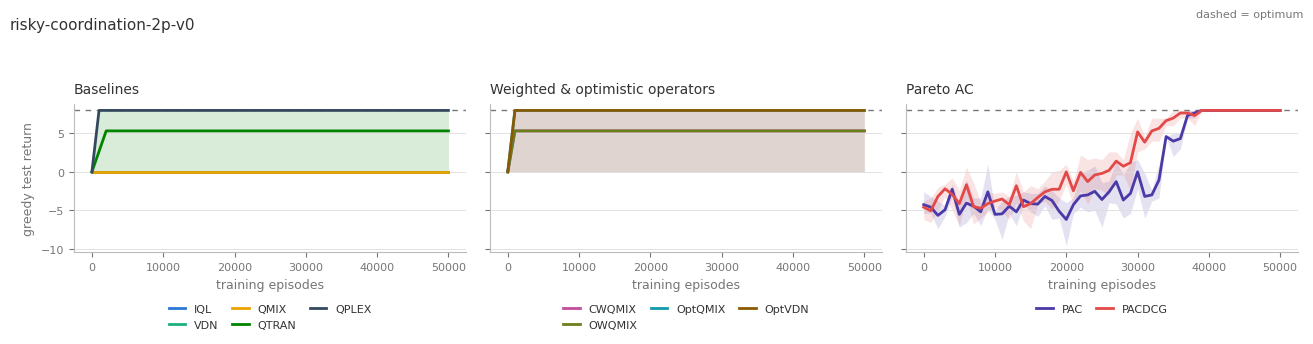

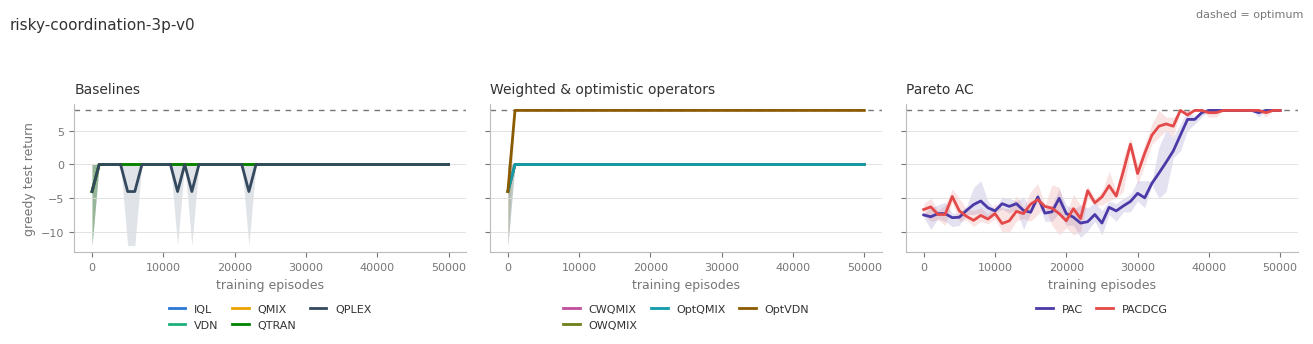

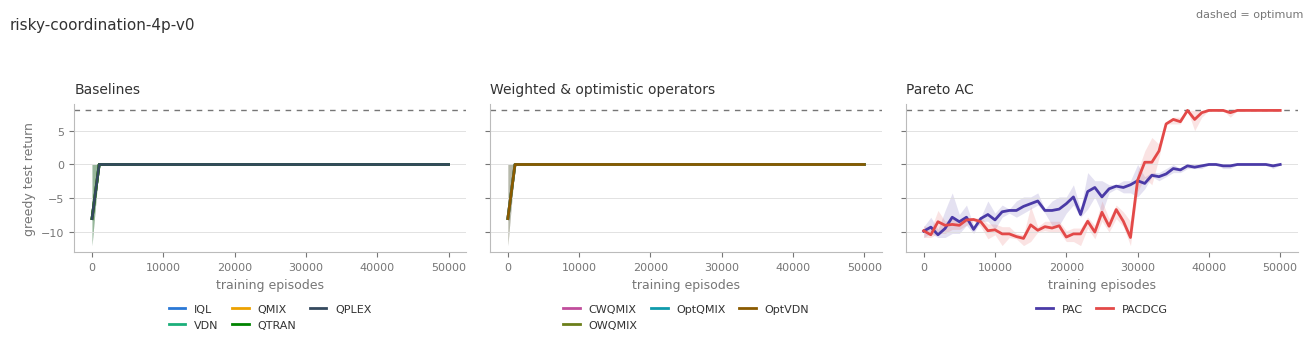

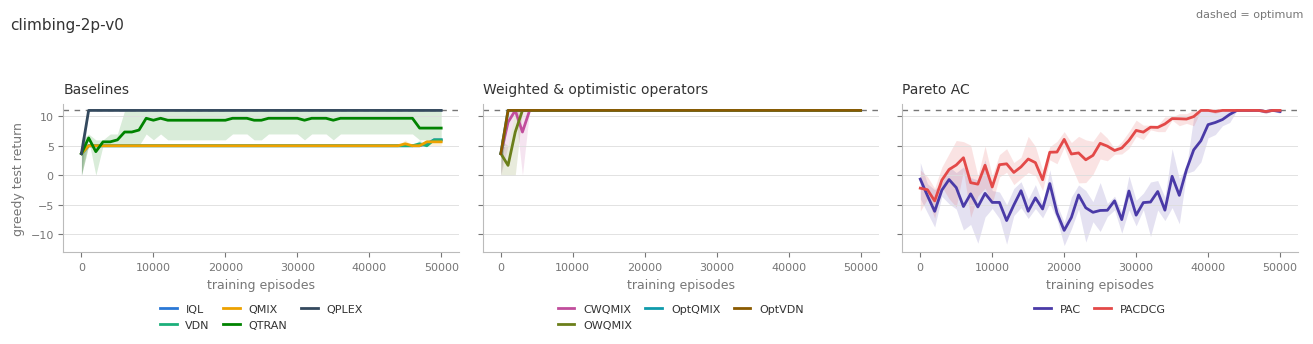

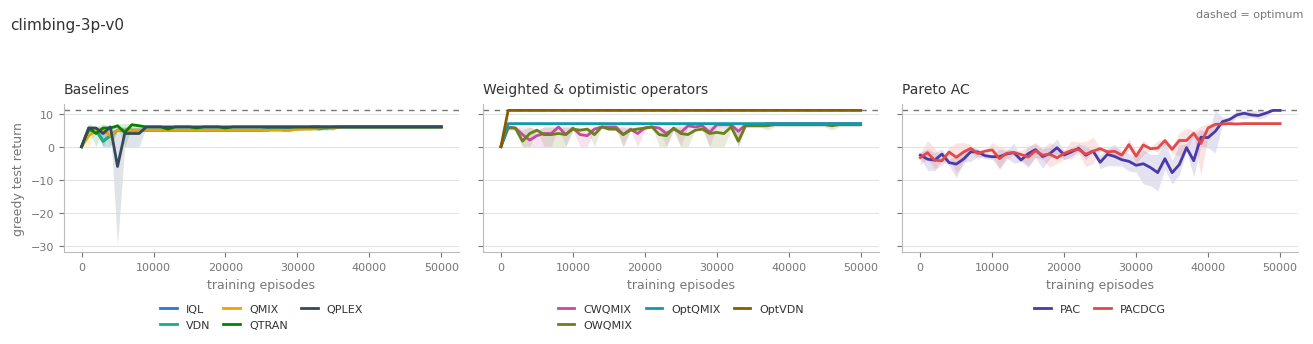

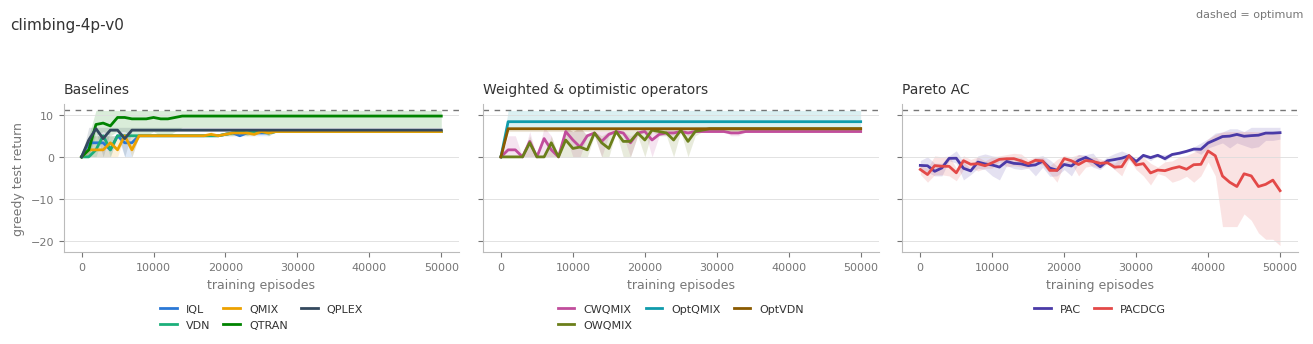

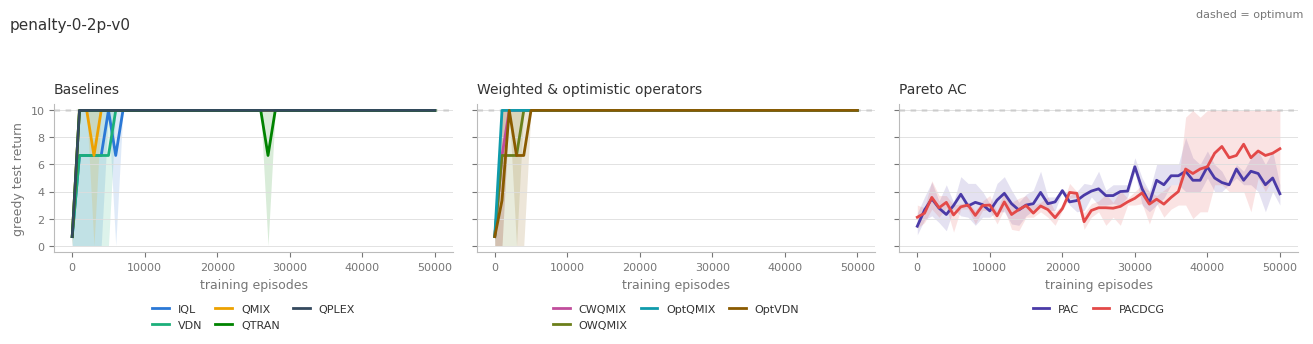

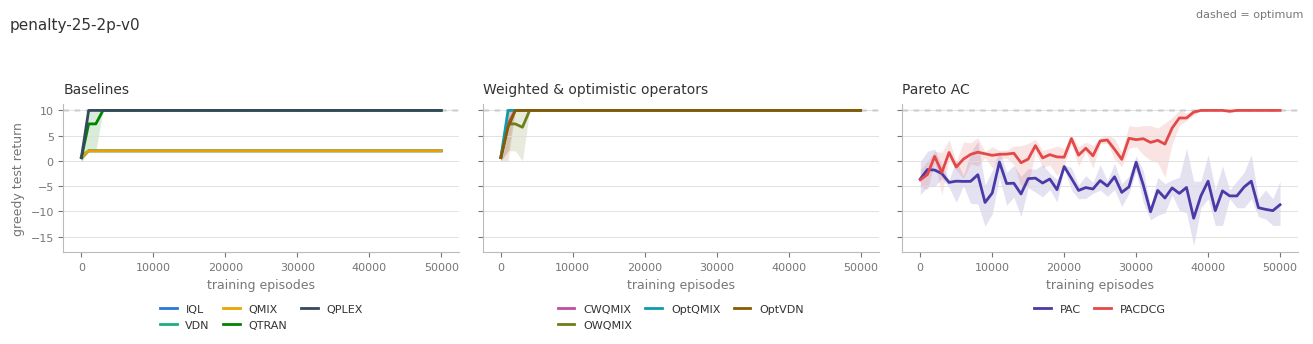

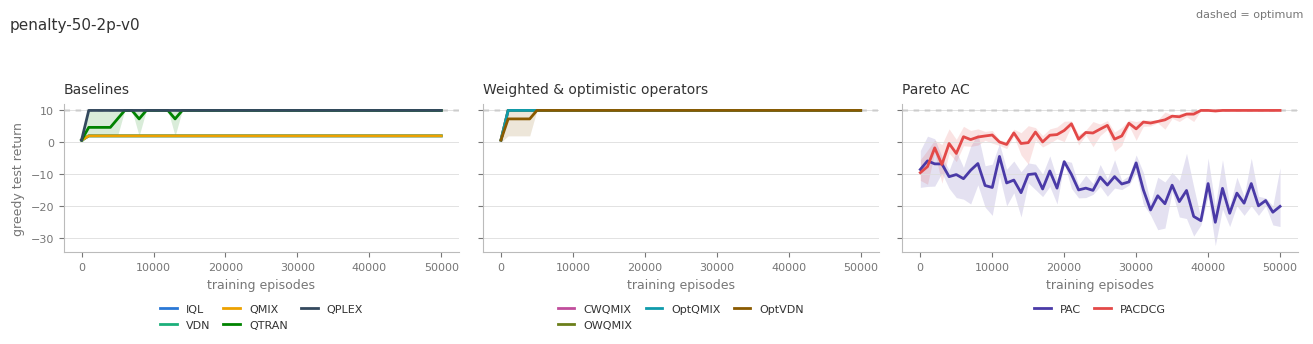

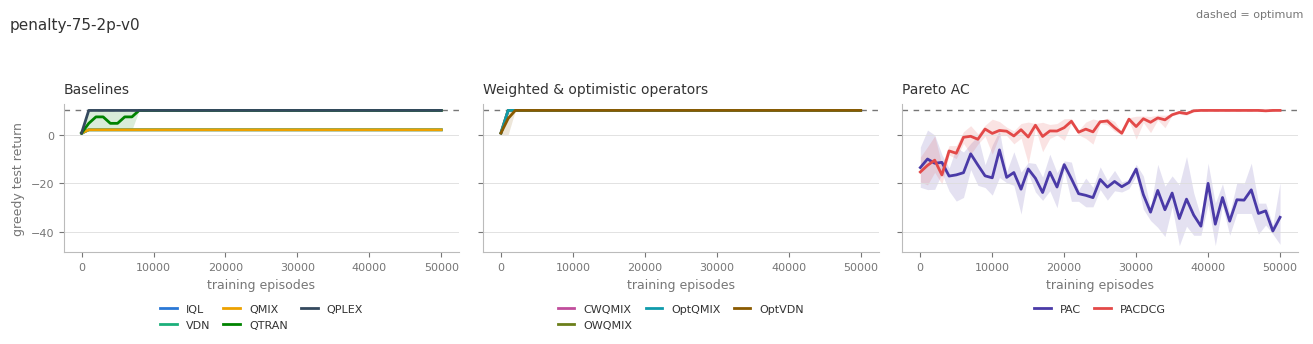

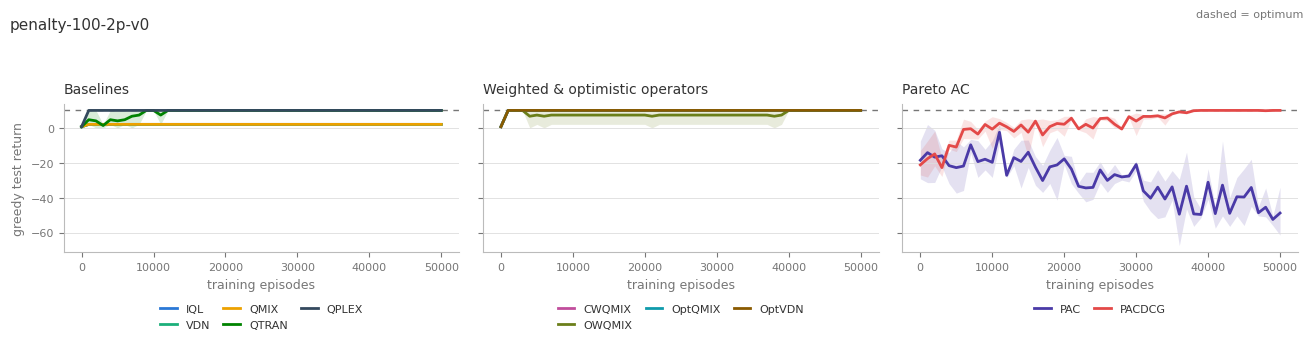

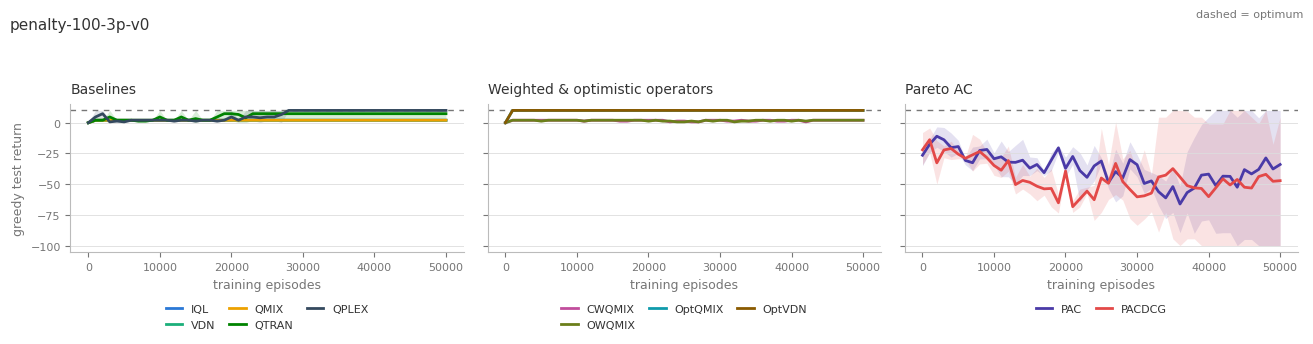

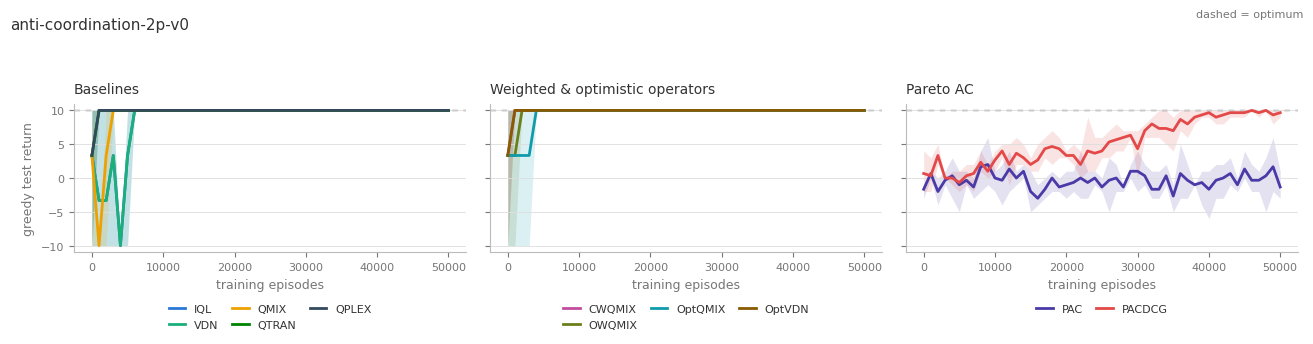

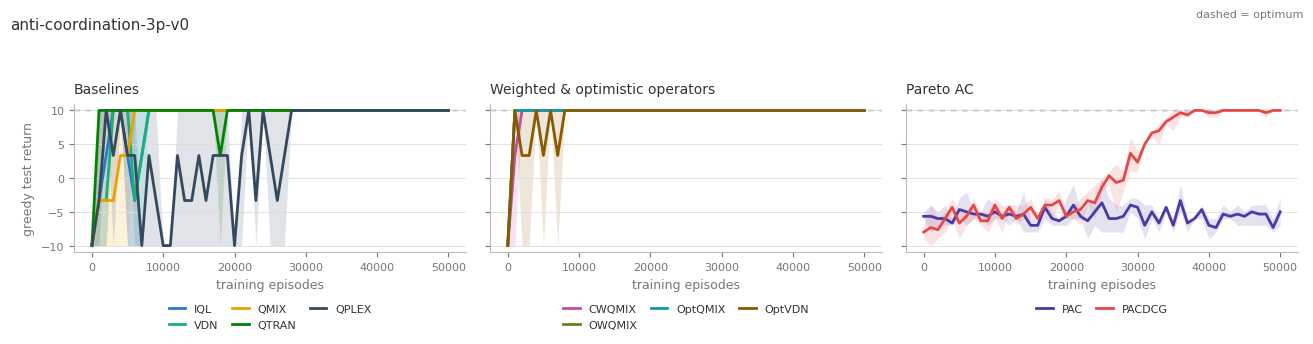

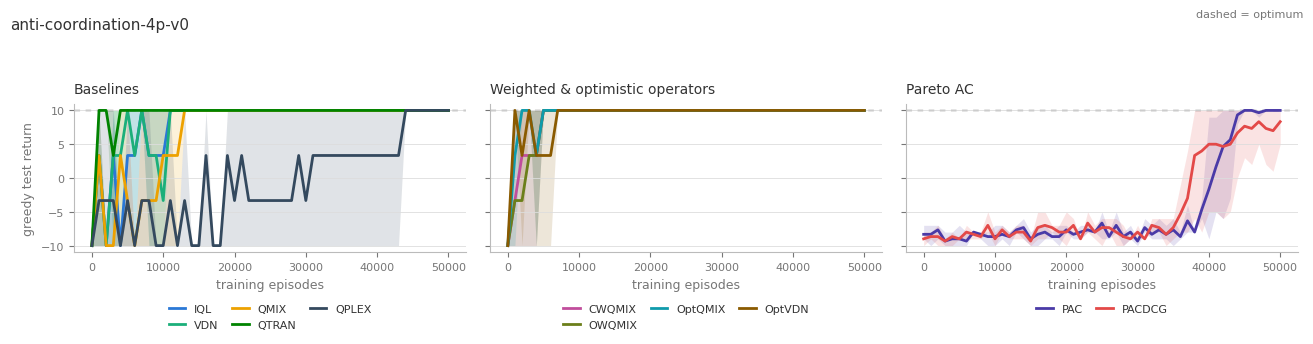

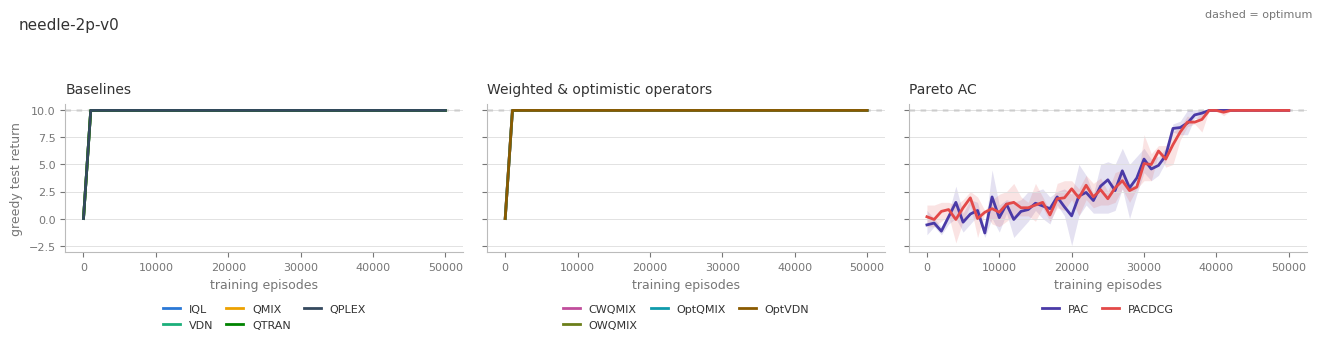

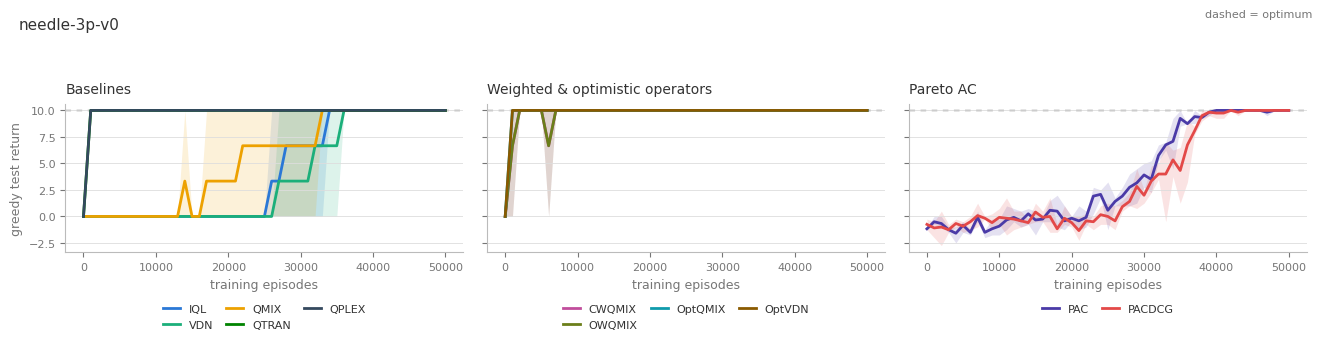

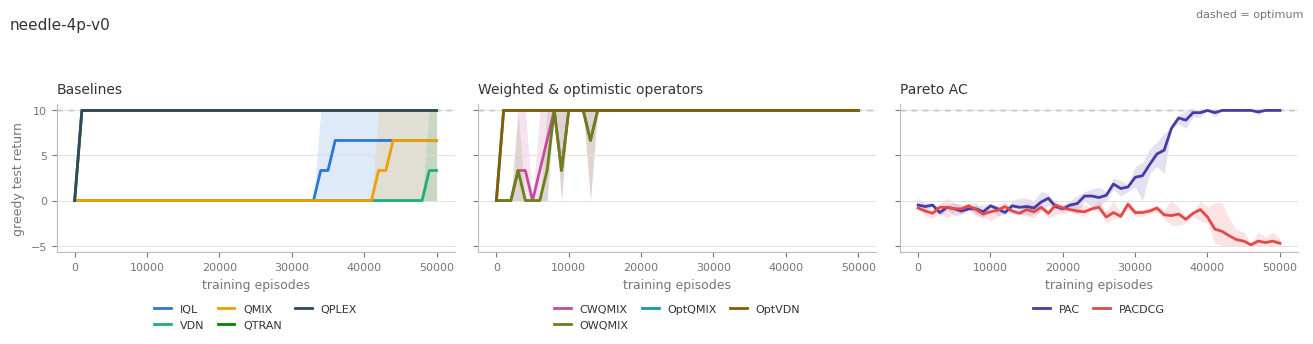

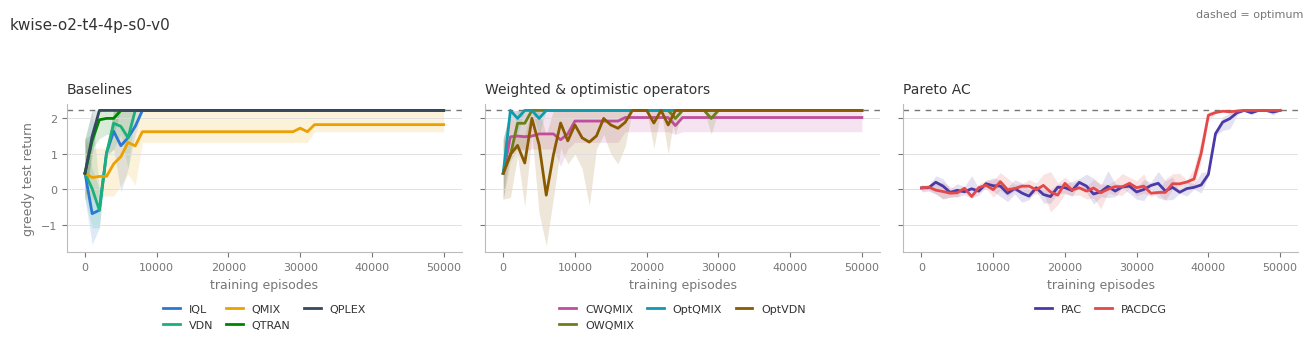

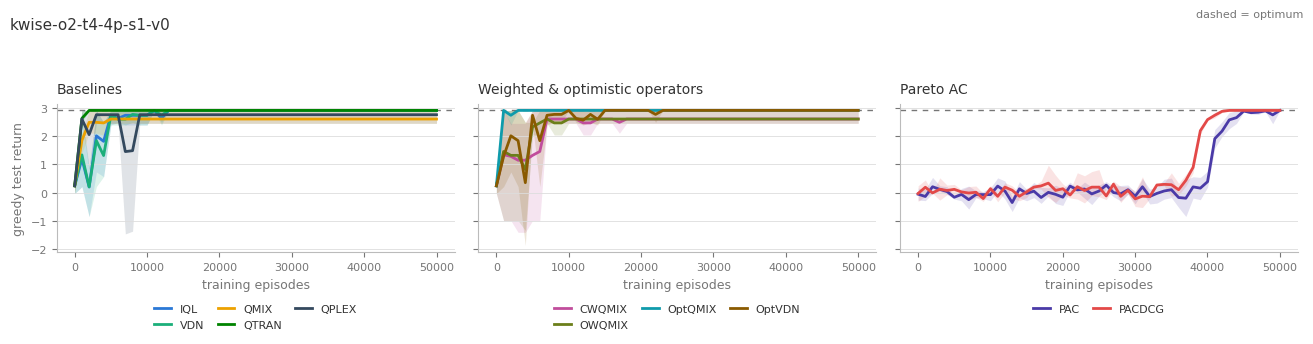

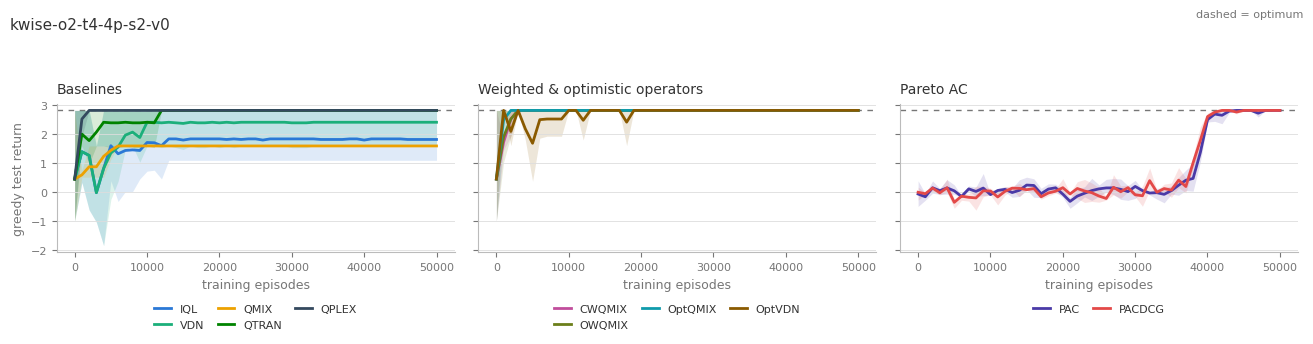

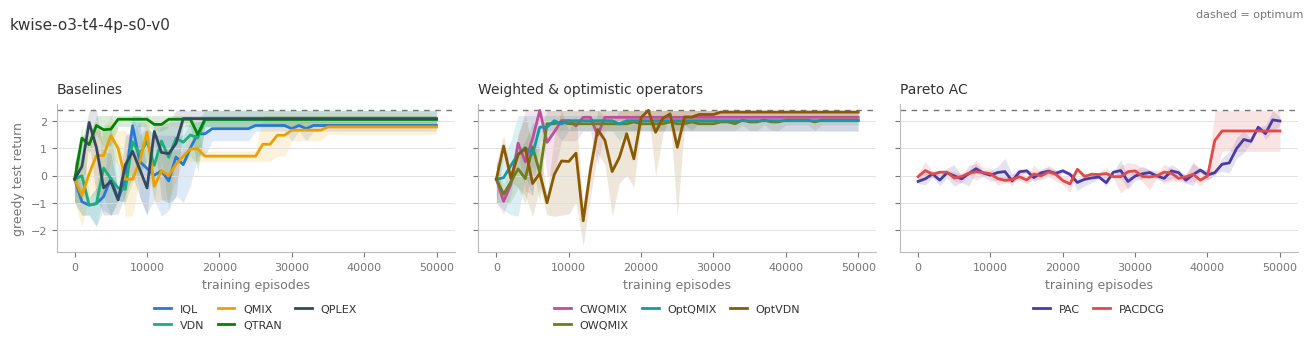

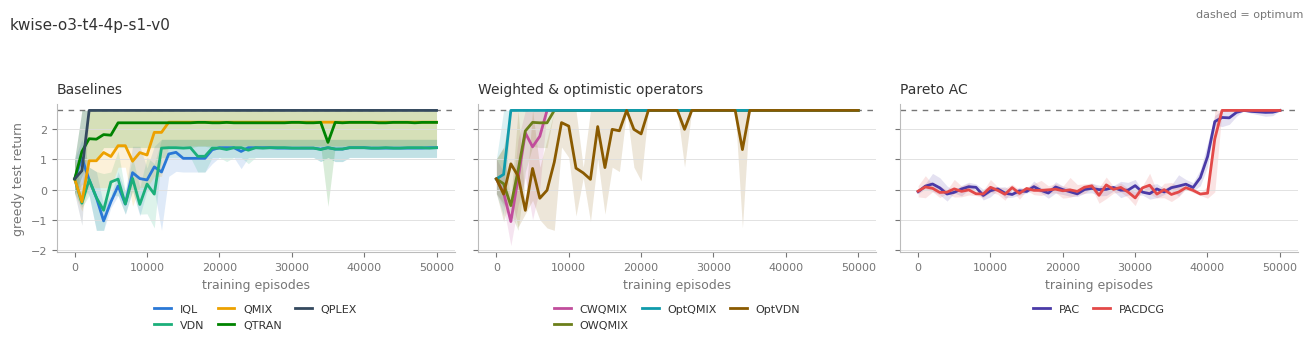

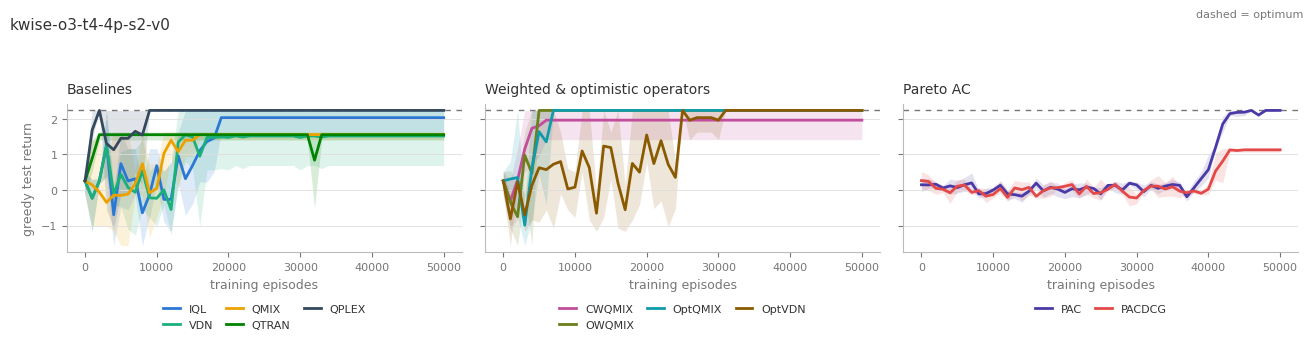

In [15]:
COLORS = {  # fixed slot per algorithm, identical in every panel and every figure
    "iql_ns": "#2a78d6", "vdn_ns": "#1baf7a", "qmix_ns": "#eda100",
    "qtran_ns": "#008300", "pac_ns": "#4a3aa7", "pac_dcg_ns": "#e34948",
    "opt_qmix_ns": "#0f9bab", "opt_vdn_ns": "#8a5a00",
    "cw_qmix_ns": "#c14d9c", "ow_qmix_ns": "#6b7f1a",
    "qplex_ns": "#34495e",
}
TEXT, MUTED = "#333333", "#767676"

FAMILIES = {  # panel groupings for the training-curve figures only
    "Baselines": ["iql_ns", "vdn_ns", "qmix_ns", "qtran_ns", "qplex_ns"],
    "Weighted & optimistic operators": ["cw_qmix_ns", "ow_qmix_ns", "opt_qmix_ns", "opt_vdn_ns"],
    "Pareto AC": ["pac_ns", "pac_dcg_ns"],
}


def game_optimum(env_id):
    kwargs = dict(gym.spec(env_id).kwargs)
    kwargs.pop("deterministic", None)
    return kwargs.pop("game_fn")(**kwargs).common_table().max()


def seed_band(group):
    """Align this (env, alg) group's curves on steps; return steps, mean, min, max."""
    n = min(len(s) for s in group["steps"])
    curves = np.array([v[:n] for v in group["test_return"]])
    return np.array(group["steps"].iloc[0][:n]), curves.mean(0), curves.min(0), curves.max(0)


for env_id in ENVS:
    env_df = df[df["env"] == env_id]
    if env_df.empty:
        continue
    optimum = game_optimum(env_id)
    # sharey=True: panels are directly comparable at a glance. label_outer() then
    # drops the y tick labels/ylabel on the inner panels since they'd just repeat
    # the leftmost panel's.
    fig, axes = plt.subplots(1, len(FAMILIES), figsize=(4.4 * len(FAMILIES), 3.9), sharey=True)
    for ax, (family, algs) in zip(axes, FAMILIES.items()):
        ax.axhline(optimum, color=MUTED, lw=1, ls=(0, (4, 4)), zorder=1)
        for alg in algs:
            group = env_df[env_df["alg"] == alg]
            if group.empty:
                continue
            steps, mean, lo, hi = seed_band(group)
            ax.fill_between(steps, lo, hi, color=COLORS[alg], alpha=0.15, lw=0)
            ax.plot(steps, mean, color=COLORS[alg], lw=2, label=ALGS[alg])
        ax.set_title(family, loc="left", fontsize=10, color=TEXT, pad=8)
        ax.set_xlabel("training episodes", fontsize=9, color=MUTED)
        ax.set_ylabel("greedy test return", fontsize=9, color=MUTED)
        ax.grid(axis="y", color="#dddddd", lw=0.6)
        ax.tick_params(colors=MUTED, labelsize=8)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_color("#bbbbbb")
        # legend sits below the panel (never inside the plot area) so it can
        # never overlap a curve, no matter where the curves end up on the y-axis
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=min(len(algs), 3),
                  frameon=False, fontsize=8, labelcolor=TEXT, handlelength=1.5, columnspacing=1.2)
        ax.label_outer()
    fig.suptitle(env_id, x=0.01, ha="left", fontsize=11, color=TEXT)
    fig.text(0.99, 0.98, "dashed = optimum", ha="right", fontsize=8, color=MUTED)
    plt.tight_layout(rect=[0, 0.02, 1, 0.93])
    plt.show()

## Wallclock training time per algorithm

Each run was run on a sinlge thread.

In [5]:
wall = (df.groupby("alg")["duration_s"]
        .agg(runs="count",
             mean_min=lambda s: s.mean() / 60,
             std_min=lambda s: s.std() / 60,
             total_hours=lambda s: s.sum() / 3600)
        .reindex(ALGS).rename(index=ALGS).round(2))
wall.index.name = "algorithm"
wall

,runs,mean_min,std_min,total_hours
algorithm,,,,
IQL,72,2.19,0.36,2.63
VDN,72,2.21,0.36,2.65
QMIX,72,2.72,0.38,3.27
QTRAN,72,3.21,0.41,3.85
PAC,72,1.00,0.12,1.20
PACDCG,72,1.42,0.23,1.70
OptQMIX,72,6.65,1.16,7.99
OptVDN,72,6.14,1.14,7.36
CWQMIX,72,5.11,0.75,6.13


## Final performance summary

Mean final return and rate at which agents choose optimal joint action

In [6]:
final_return = (df.pivot_table(index="env", columns="alg", values="final_return")
                .reindex(index=ENVS, columns=list(ALGS)).rename(columns=ALGS))
final_return.insert(0, "optimum", [game_optimum(e) for e in final_return.index])
final_return.round(2)

alg,optimum,IQL,VDN,QMIX,QTRAN,PAC,PACDCG,OptQMIX,OptVDN,CWQMIX,OWQMIX,QPLEX
env,,,,,,,,,,,,
risky-coordination-2p-v0,8.00,0.00,0.00,0.00,5.33,8.00,8.00,8.00,8.00,5.33,5.33,8.00
risky-coordination-3p-v0,8.00,0.00,0.00,0.00,0.00,8.00,8.00,0.00,8.00,0.00,0.00,0.00
risky-coordination-4p-v0,8.00,0.00,0.00,0.00,0.00,0.00,8.00,0.00,0.00,0.00,0.00,0.00
climbing-2p-v0,11.00,6.00,6.00,5.67,8.00,10.82,11.00,11.00,11.00,11.00,11.00,11.00
climbing-3p-v0,11.00,6.00,6.00,6.00,6.00,11.00,7.00,7.00,11.00,7.00,6.67,6.00
climbing-4p-v0,11.00,6.00,6.00,6.00,9.67,5.73,-8.00,8.33,6.67,6.00,6.67,6.33
penalty-0-2p-v0,10.00,10.00,10.00,10.00,10.00,3.83,7.17,10.00,10.00,10.00,10.00,10.00
penalty-25-2p-v0,10.00,2.00,2.00,2.00,10.00,-8.67,10.00,10.00,10.00,10.00,10.00,10.00
penalty-50-2p-v0,10.00,2.00,2.00,2.00,10.00,-20.17,10.00,10.00,10.00,10.00,10.00,10.00


In [7]:
optimal_rate = (df.pivot_table(index="env", columns="alg", values="final_optimal")
                .reindex(index=ENVS, columns=list(ALGS)).rename(columns=ALGS))
optimal_rate.round(2)

alg,IQL,VDN,QMIX,QTRAN,PAC,PACDCG,OptQMIX,OptVDN,CWQMIX,OWQMIX,QPLEX
env,,,,,,,,,,,
risky-coordination-2p-v0,0.00,0.00,0.00,0.67,1.00,1.00,1.00,1.00,0.67,0.67,1.00
risky-coordination-3p-v0,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00
risky-coordination-4p-v0,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
climbing-2p-v0,0.00,0.00,0.00,0.33,0.98,1.00,1.00,1.00,1.00,1.00,1.00
climbing-3p-v0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00
climbing-4p-v0,0.00,0.00,0.00,0.67,0.00,0.00,0.33,0.00,0.00,0.00,0.00
penalty-0-2p-v0,1.00,1.00,1.00,1.00,0.38,0.72,1.00,1.00,1.00,1.00,1.00
penalty-25-2p-v0,0.00,0.00,0.00,1.00,0.47,1.00,1.00,1.00,1.00,1.00,1.00
penalty-50-2p-v0,0.00,0.00,0.00,1.00,0.48,1.00,1.00,1.00,1.00,1.00,1.00
